**1-Install Biopython**

In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 20.6 MB/s eta 0:00:00


**2-Import modules**

In [2]:
from Bio import Entrez
from Bio import SeqIO
import pandas as pd

**3-Email for NCBI**

In [3]:
Entrez.email = "valsolis1601@gmail.com"

**4-Define Accession Numbers**

For this example, we will use publicly available mitochondrial DNA sequences from three bee species retrieved from the NCBI database. Each accession number uniquely identifies a biological sequence stored in GenBank.

In [4]:
accessions = [
    "NC_001566",   # Apis mellifera
    "NC_015770",   # Bombus terrestris
    "NC_028009"    # Melipona bicolor
]

**5-Download sequences**

In [5]:
records = []

for acc in accessions:

    handle = Entrez.efetch(
        db="nucleotide",
        id=acc,
        rettype="fasta",
        retmode="text"
    )

    record = SeqIO.read(
        handle,
        "fasta"
    )

    records.append(record)

print("Sequences:", len(records))

Sequences: 3


**6-View length**

In [6]:
for record in records:

    print(
        record.id,
        len(record.seq)
    )

NC_001566.1 16343
NC_015770.1 15655298
NC_028009.1 153398


**7-Similarity function**

Let's compare position by position.

In [7]:
def similarity(seq1, seq2):

    length = min(
        len(seq1),
        len(seq2)
    )

    matches = sum(
        a == b
        for a, b in zip(
            seq1[:length],
            seq2[:length]
        )
    )

    return matches / length * 100

**8-Similarity matrix**

In [8]:
species = [
    r.id
    for r in records
]

matrix = []

for r1 in records:

    row = []

    for r2 in records:

        sim = similarity(
            str(r1.seq),
            str(r2.seq)
        )

        row.append(
            round(sim,2)
        )

    matrix.append(row)

df = pd.DataFrame(
    matrix,
    index=species,
    columns=species
)

df

,NC_001566.1,NC_015770.1,NC_028009.1
NC_001566.1,100.00,25.29,30.30
NC_015770.1,25.29,100.00,25.22
NC_028009.1,30.30,25.22,100.00


**9-Heatmap**

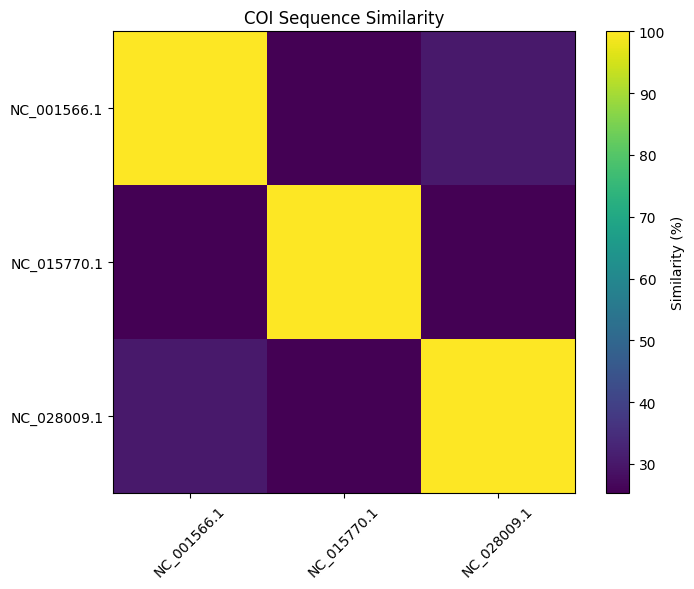

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(df)

plt.colorbar(
    label="Similarity (%)"
)

plt.xticks(
    range(len(species)),
    species,
    rotation=45
)

plt.yticks(
    range(len(species)),
    species
)

plt.title(
    "COI Sequence Similarity"
)

plt.show()

**10-Convert Similarity to Distance**

In [10]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import numpy as np

In [11]:
distance_matrix = 100 - df

**11-Prepare Distance Matrix for Clustering**

In [12]:
condensed = squareform(
    distance_matrix.values,
    checks=False
)

**12-Perform Hierarchical Clustering**

In [13]:
linkage_matrix = linkage(
    condensed,
    method="average"
)

**13-Generate Dendrogram**

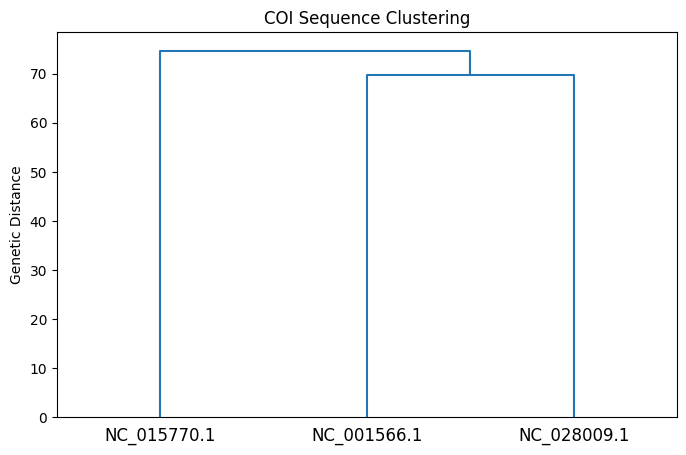

In [14]:
plt.figure(figsize=(8,5))

dendrogram(
    linkage_matrix,
    labels=df.index.tolist()
)

plt.title(
    "COI Sequence Clustering"
)

plt.ylabel(
    "Genetic Distance"
)

plt.show()